In [17]:
#!/usr/bin/env python3
# mmca_stage_intervention_fixed_with_deg.py
"""
Fixed MMCA on 3-uniform hypergraph with stage intervention + save degree distribution.

变动（新增）:
 - 每次生成 hyperedges 后计算节点度 degree，并保存 per-run CSV: out_dir/deg_run{r:03d}.csv
 - 所有重复结束后，汇总每个 degree 值的节点占比(mean ± std)，保存为 out_dir/degree_hist_summary.csv
其他逻辑保持和你提供的脚本一致（pre/post 保存等）。
"""

import os
import numpy as np
import random
import math
import pandas as pd
from time import time

# ---------------- hypergraph generator (same as yours) ----------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# ---------------- HyperSISModel (same as yours, omitted here for brevity) ----------------
class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)    # shape (m,3)
        self.n = n
        self.m = self.hyperedges.shape[0]
        # convenience arrays (may contain -1 for deleted edges)
        self.edge_i = self.hyperedges[:, 0].copy()
        self.edge_j = self.hyperedges[:, 1].copy()
        self.edge_k = self.hyperedges[:, 2].copy()
        # mask of active edges (True = active)
        self.active_edges = np.ones(self.m, dtype=bool)
        # build incidence list
        self._build_node_incidence()

    def _build_node_incidence(self):
        """
        Build node_edge_pos: for each node, list of (edge_idx, position_in_edge).
        Ignores edges with active_edges==False or with negative node indices.
        """
        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            if not self.active_edges[ei]:
                continue
            a, b, c = self.hyperedges[ei]
            # safety: skip if any endpoint is invalid
            if a < 0 or b < 0 or c < 0:
                continue
            self.node_edge_pos[a].append((ei, 0))
            self.node_edge_pos[b].append((ei, 1))
            self.node_edge_pos[c].append((ei, 2))

    def _compute_edge_products(self, p):
        """
        Compute product of the two "other" nodes for each edge position:
          prod_pos0[e] = p_j * p_k  (when considering node edge_i)
          prod_pos1[e] = p_i * p_k
          prod_pos2[e] = p_i * p_j
        For inactive edges, return 0 so they don't contribute to infection.
        """
        # avoid negative indexing by clipping indices to valid range, but we'll mask after
        clip_idx_i = np.clip(self.edge_i, 0, self.n - 1)
        clip_idx_j = np.clip(self.edge_j, 0, self.n - 1)
        clip_idx_k = np.clip(self.edge_k, 0, self.n - 1)

        p_i = p[clip_idx_i]
        p_j = p[clip_idx_j]
        p_k = p[clip_idx_k]

        prod_pos0 = p_j * p_k
        prod_pos1 = p_i * p_k
        prod_pos2 = p_i * p_j

        # zero out contributions of inactive edges
        if not self.active_edges.all():
            mask = ~self.active_edges
            prod_pos0[mask] = 0.0
            prod_pos1[mask] = 0.0
            prod_pos2[mask] = 0.0

        return prod_pos0, prod_pos1, prod_pos2

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        """
        Update Theta_e using Phi_e = product_j p_j for each edge.
        For inactive edges: set Phi=0 and Theta_new=0 (remain inactive).
        Returns Theta_new (length m) and Phi (length m).
        """
        # compute Phi using clipped indices then mask
        clip_idx_i = np.clip(self.edge_i, 0, self.n - 1)
        clip_idx_j = np.clip(self.edge_j, 0, self.n - 1)
        clip_idx_k = np.clip(self.edge_k, 0, self.n - 1)
        p_i = p[clip_idx_i]
        p_j = p[clip_idx_j]
        p_k = p[clip_idx_k]
        Phi = p_i * p_j * p_k

        # for inactive edges set Phi to 0 and Theta forced to 0
        if not self.active_edges.all():
            Phi[~self.active_edges] = 0.0

        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        # ensure inactive edges keep Theta=0
        if not self.active_edges.all():
            Theta_new[~self.active_edges] = 0.0

        Theta_new = np.clip(Theta_new, 0.0, 1.0)
        return Theta_new, Phi

    def _random_new_edge(self, existing_set, rng, d=3, max_tries=500):
        """
        Sample a fresh new d-tuple of nodes not in existing_set.
        rng is np.random.Generator or numpy.random module.
        """
        tries = 0
        while tries < max_tries:
            nodes = rng.choice(self.n, size=(d,), replace=False)
            nodes.sort()
            tup = tuple(int(x) for x in nodes.tolist())
            if tup not in existing_set:
                return np.array(nodes, dtype=int)
            tries += 1
        # last resort, return some sample (may collide)
        nodes = rng.choice(self.n, size=(d,), replace=False)
        nodes.sort()
        return np.array(nodes, dtype=int)

    def run_mmca_stage_intervention(self,
                                    beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                                    T_pre_max=200, T_post=100, init_frac=0.01,
                                    w_frac=0.1,   # fraction of edges to immunize at stage
                                    seed=None, verbose=False, rewire=True, theta_new_on_rewire=0.1):
        """
        Run MMCA pre-phase then stage intervention then post-phase.

        New parameter:
          rewire: bool, if False => permanently remove selected edges (no rewire).
                  if True  => rewire selected edges randomly (default behavior).
          theta_new_on_rewire: initial Theta for newly rewired edges (if rewire==True)

        Returns same structure as original function.
        """
        rng = np.random.default_rng(seed) if seed is not None else np.random

        # initialize p and Theta
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float) * 1.0
        edge_set = set(tuple(row.tolist()) for row in self.hyperedges if row[0] >= 0)

        pre_rho = []
        pre_theta_mean = []

        # pre-phase
        for t in range(T_pre_max):
            pre_rho.append(p.mean())
            pre_theta_mean.append(Theta.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            # Q per node
            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    # ignore inactive edges because node_edge_pos was built ignoring them
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta, Phi = self._update_theta_from_p(p, Theta, eta, gamma)

            p = p_next

            # if verbose and (t % 50 == 0):
            #     print(f"[pre t={t}] rho={pre_rho[-1]:.6f}  meanTheta={pre_theta_mean[-1]:.6f}")

        # steady-time and pre summary
        t_ss = T_pre_max - 1
        pre_ss_rho_mean = float(pre_rho[-1])

        # compute Phi and select top edges
        p_for_phi = p.copy()
        # compute Phi for all edges (inactive ones will be zeroed in _update_theta_from_p)
        clip_idx_i = np.clip(self.edge_i, 0, self.n - 1)
        clip_idx_j = np.clip(self.edge_j, 0, self.n - 1)
        clip_idx_k = np.clip(self.edge_k, 0, self.n - 1)
        Phi_e = p_for_phi[clip_idx_i] * p_for_phi[clip_idx_j] * p_for_phi[clip_idx_k]
        # zero inactive edges to avoid selecting them
        if not self.active_edges.all():
            Phi_e[~self.active_edges] = 0.0
        # 按风险降序排序，选择风险最高的w_frac比例的超边
        sorted_idx = np.argsort(-Phi_e)
        num_rewire = max(1, int(np.ceil(w_frac * self.m))) if w_frac > 0 else 0
        top_idx = sorted_idx[:num_rewire]

        # Intervention: either permanently delete or rewire
        if num_rewire > 0:
            if rewire:
                # remove old tuples from edge_set first
                for ei in top_idx:
                    tup = tuple(int(x) for x in self.hyperedges[ei].tolist())
                    if tup in edge_set:
                        edge_set.remove(tup)
                    # mark temporarily inactive so we don't accidentally reuse same tuple
                    self.active_edges[ei] = False
                    # mark hyperedge placeholder to avoid duplication in set
                    self.hyperedges[ei] = np.array([-1, -1, -1], dtype=int)
                    Theta[ei] = 0.0
                # now create new edges for those positions
                for ei in top_idx:
                    new_edge = self._random_new_edge(existing_set=edge_set, rng=rng, d=3, max_tries=2000)
                    new_tup = tuple(int(x) for x in new_edge.tolist())
                    self.hyperedges[ei] = new_edge
                    self.edge_i[ei], self.edge_j[ei], self.edge_k[ei] = new_edge
                    edge_set.add(new_tup)
                    self.active_edges[ei] = True
                    Theta[ei] = float(theta_new_on_rewire)
                # rebuild incidence
                self._build_node_incidence()
            else:
                # permanent deletion: mark edges inactive and remove tuples
                for ei in top_idx:
                    tup = tuple(int(x) for x in self.hyperedges[ei].tolist())
                    if tup in edge_set:
                        edge_set.remove(tup)
                    self.hyperedges[ei] = np.array([-1, -1, -1], dtype=int)
                    self.active_edges[ei] = False
                    Theta[ei] = 0.0
                # update edge index arrays (keep -1 values)
                self.edge_i = self.hyperedges[:, 0].copy()
                self.edge_j = self.hyperedges[:, 1].copy()
                self.edge_k = self.hyperedges[:, 2].copy()
                # rebuild incidence which will ignore deleted edges
                self._build_node_incidence()

        # post-phase
        post_rho = []
        post_theta_mean = []
        for t in range(T_post):
            post_rho.append(p.mean())
            post_theta_mean.append(Theta.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta, Phi = self._update_theta_from_p(p, Theta, eta, gamma)
            p = p_next

        # append final stats
        post_rho.append(p.mean())
        post_theta_mean.append(Theta.mean())

        post_end_rho = float(post_rho[-1])

        info = {
            't_ss': int(t_ss),
            'num_rewired': int(num_rewire),
            'pre_ss_rho_mean': float(pre_ss_rho_mean),
            'post_end_rho_mean': float(post_end_rho)
        }

        return np.array(pre_rho), np.array(pre_theta_mean), np.array(post_rho), np.array(post_theta_mean), info

In [18]:
#!/usr/bin/env python3
# mmca_stage_intervention_fixed_with_deg_main.py
"""
随机重连版本 - 主程序部分
运行实验并保存结果，包含免疫前后度分布对比
"""

import os
import numpy as np
import pandas as pd
from time import time

def compute_degree_distribution(hyperedges, n):
    """计算超图的度分布"""
    deg = np.zeros(n, dtype=int)
    for (a, b, c) in hyperedges:
        deg[int(a)] += 1
        deg[int(b)] += 1
        deg[int(c)] += 1
    return deg

if __name__ == "__main__":
    # ---- 参数设置 ----
    n = 1500
    kappa = 6.0
    beta = 0.25
    mu = 0.1
    T_pre_max = 400
    T_post = 300
    init_frac = 0.3
    seed = 12345
    eta = 0.6
    gamma = 0.02

    w_frac = 0.8
    R = 20

    out_dir = "stage_intervention_runs_fixed_random"
    os.makedirs(out_dir, exist_ok=True)

    summary_rows = []
    t0_all = time()
    all_pre_rho = []
    all_post_rho = []

    # 用来汇总每次的 degree fraction histogram（以 degree 做索引）
    degree_fraction_list_before = []  # 免疫前的度分布
    degree_fraction_list_after = []   # 免疫后的度分布

    for r in range(R):
        gen_seed = None if seed is None else (seed + r)
        run_seed = None if seed is None else (seed + 1000 + r)

        # 生成超图
        hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed, batch_size=3000)

        # ---- 计算免疫前的节点度 ----
        deg_before = compute_degree_distribution(hyperedges, n)
        deg_before_df = pd.DataFrame({'node': np.arange(n), 'degree': deg_before})
        # deg_before_fn = os.path.join(out_dir, f"deg_before_run{r:03d}.csv")
        # deg_before_df.to_csv(deg_before_fn, index=False)
        # print(f"[run {r}] 免疫前度分布 saved -> {deg_before_fn}")

        # 计算免疫前的度分布直方图
        unique_before, counts_before = np.unique(deg_before, return_counts=True)
        frac_before = counts_before.astype(float) / float(n)
        deg_frac_dict_before = dict(zip(unique_before.tolist(), frac_before.tolist()))
        degree_fraction_list_before.append(deg_frac_dict_before)

        # ----- 运行模型 -----
        model = HyperSISModel(hyperedges, n)

        # 调用 run_mmca_stage_intervention，rewire=True（使用随机重连）
        pre_rho, pre_theta_mean, post_rho, post_theta_mean, info = model.run_mmca_stage_intervention(
            beta_d=beta, mu=mu, eta=eta, gamma=gamma,
            T_pre_max=T_pre_max, T_post=T_post,
            init_frac=init_frac, w_frac=w_frac,
            seed=run_seed, verbose=False,
            rewire=True,                # 使用随机重连
            theta_new_on_rewire=0.1
        )

        all_pre_rho.append(pre_rho)
        all_post_rho.append(post_rho)

        # ---- 计算免疫后的节点度 ----
        # 从模型中获取干预后的超图
        hyperedges_after = model.hyperedges
        deg_after = compute_degree_distribution(hyperedges_after, n)
        deg_after_df = pd.DataFrame({'node': np.arange(n), 'degree': deg_after})
        # deg_after_fn = os.path.join(out_dir, f"deg_after_run{r:03d}.csv")
        # deg_after_df.to_csv(deg_after_fn, index=False)
        # print(f"[run {r}] 免疫后度分布 saved -> {deg_after_fn}")

        # 计算免疫后的度分布直方图
        unique_after, counts_after = np.unique(deg_after, return_counts=True)
        frac_after = counts_after.astype(float) / float(n)
        deg_frac_dict_after = dict(zip(unique_after.tolist(), frac_after.tolist()))
        degree_fraction_list_after.append(deg_frac_dict_after)

        summary_rows.append({
            'run': r,
            't_ss': info['t_ss'],
            'num_rewired': info['num_rewired'],
            'pre_ss_rho_mean': info['pre_ss_rho_mean'],
            'post_end_rho_mean': info['post_end_rho_mean']
        })

        print(f"[run {r}] done, pre_rho_last={pre_rho[-1]:.4f}, post_rho_last={post_rho[-1]:.4f}")

    # Save pre/post as before
    df_pre = pd.DataFrame(all_pre_rho).T
    df_post = pd.DataFrame(all_post_rho).T
    df_pre.to_csv(os.path.join(out_dir, "pre_rho_all.csv"), index=False, header=False)
    df_post.to_csv(os.path.join(out_dir, "post_rho_all.csv"), index=False, header=False)
    df_summary = pd.DataFrame(summary_rows)
    df_summary.to_csv(os.path.join(out_dir, "summary_stage_intervention.csv"), index=False)
    print("✅ 已保存 pre/post 结果与 summary")

    # ---- 汇总免疫前后的度分布，保存 summary CSV ----
    def create_degree_summary(degree_fraction_list, n, suffix):
        """创建度分布汇总"""
        all_degrees = set()
        for dfd in degree_fraction_list:
            all_degrees.update(dfd.keys())
        maxdeg = max(all_degrees) if len(all_degrees) > 0 else 0
        deg_range = np.arange(0, maxdeg + 1)

        # 构建矩阵: rows = runs, cols = degree values
        frac_mat = np.zeros((len(degree_fraction_list), len(deg_range)), dtype=float)
        for i, dfd in enumerate(degree_fraction_list):
            for deg_val, frac_val in dfd.items():
                frac_mat[i, int(deg_val)] = frac_val

        mean_frac = frac_mat.mean(axis=0)
        std_frac = frac_mat.std(axis=0, ddof=0)
        mean_count = mean_frac * float(n)

        deg_summary_df = pd.DataFrame({
            'degree': deg_range,
            'mean_fraction': mean_frac,
            'std_fraction': std_frac,
            'mean_count': mean_count
        })
        deg_summary_fn = os.path.join(out_dir, f"degree_hist_summary_{suffix}.csv")
        deg_summary_df.to_csv(deg_summary_fn, index=False, float_format="%.6f")
        print(f"✅ 已保存{suffix}度分布汇总 -> {deg_summary_fn}")
        return deg_summary_df, deg_range, mean_frac, std_frac

    # 创建免疫前后的度分布汇总
    deg_summary_before, deg_range_before, mean_frac_before, std_frac_before = create_degree_summary(
        degree_fraction_list_before, n, "before")
    
    deg_summary_after, deg_range_after, mean_frac_after, std_frac_after = create_degree_summary(
        degree_fraction_list_after, n, "after")

    print("总运行时间: {:.1f} 秒".format(time() - t0_all))

[run 0] done, pre_rho_last=0.4294, post_rho_last=0.4297
[run 1] done, pre_rho_last=0.4285, post_rho_last=0.4286
[run 2] done, pre_rho_last=0.4284, post_rho_last=0.4291
[run 3] done, pre_rho_last=0.4286, post_rho_last=0.4286
[run 4] done, pre_rho_last=0.4294, post_rho_last=0.4292
[run 5] done, pre_rho_last=0.4297, post_rho_last=0.4303
[run 6] done, pre_rho_last=0.4288, post_rho_last=0.4295
[run 7] done, pre_rho_last=0.4292, post_rho_last=0.4303
[run 8] done, pre_rho_last=0.4290, post_rho_last=0.4296
[run 9] done, pre_rho_last=0.4294, post_rho_last=0.4296
[run 10] done, pre_rho_last=0.4285, post_rho_last=0.4287
[run 11] done, pre_rho_last=0.4304, post_rho_last=0.4289
[run 12] done, pre_rho_last=0.4290, post_rho_last=0.4297
[run 13] done, pre_rho_last=0.4292, post_rho_last=0.4286
[run 14] done, pre_rho_last=0.4299, post_rho_last=0.4293
[run 15] done, pre_rho_last=0.4300, post_rho_last=0.4295
[run 16] done, pre_rho_last=0.4296, post_rho_last=0.4301
[run 17] done, pre_rho_last=0.4282, post_

Saved figure to ./stage_intervention_runs_fixed_random\compare_pre_post_rho_random.png


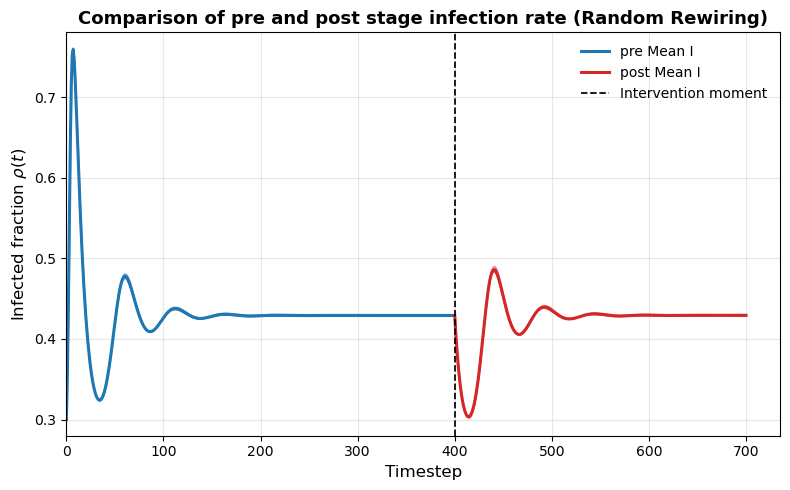

In [19]:
#!/usr/bin/env python3
# plot_stage_intervention_with_deg.py
"""
随机重连版本 - 绘图部分
绘制感染率时间序列和度分布图，包含免疫前后度分布对比直方图
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 配置 ==========
out_dir = "./stage_intervention_runs_fixed_random"
plot_individual_runs = True
save_png = True

png_name_times = "compare_pre_post_rho_random.png"
png_name_deg = "degree_distribution_random.png"
png_name_deg_comparison = "degree_distribution_comparison_histogram_random.png"

# ========== 读取数据 ==========
pre_file = os.path.join(out_dir, "pre_rho_all.csv")
post_file = os.path.join(out_dir, "post_rho_all.csv")
summary_file = os.path.join(out_dir, "summary_stage_intervention.csv")
deg_summary_before_file = os.path.join(out_dir, "degree_hist_summary_before.csv")
deg_summary_after_file = os.path.join(out_dir, "degree_hist_summary_after.csv")

# 检查文件是否存在
for fn in (pre_file, post_file, summary_file, deg_summary_before_file, deg_summary_after_file):
    if not os.path.exists(fn):
        print(f"[WARNING] 找不到：{fn}")

# 读取感染率数据
pre_rho_all = pd.read_csv(pre_file, header=None).to_numpy()
post_rho_all = pd.read_csv(post_file, header=None).to_numpy()
df_summary = pd.read_csv(summary_file)

T_pre, R_pre = pre_rho_all.shape
T_post, R_post = post_rho_all.shape
R = min(R_pre, R_post)

if R_pre != R_post:
    pre_rho_all = pre_rho_all[:, :R]
    post_rho_all = post_rho_all[:, :R]

mean_pre = pre_rho_all.mean(axis=1)
std_pre  = pre_rho_all.std(axis=1)
mean_post = post_rho_all.mean(axis=1)
std_post  = post_rho_all.std(axis=1)

t_pre = np.arange(T_pre)
t_post = np.arange(T_post) + T_pre

# ---------- 时序图 ----------
plt.figure(figsize=(8,5))
if plot_individual_runs:
    alpha_line = 0.25
    for col in range(R):
        plt.plot(t_pre, pre_rho_all[:, col], color='#1f77b4', alpha=alpha_line, linewidth=0.9)
        plt.plot(t_post, post_rho_all[:, col], color='#d62728', alpha=alpha_line, linewidth=0.9)

plt.plot(t_pre, mean_pre, color='#1f77b4', lw=2.2, label='pre Mean I')
plt.fill_between(t_pre, mean_pre - std_pre, mean_pre + std_pre, color='#1f77b4', alpha=0.25)
plt.plot(t_post, mean_post, color='#d62728', lw=2.2, label='post Mean I')
plt.fill_between(t_post, mean_post - std_post, mean_post + std_post, color='#d62728', alpha=0.25)

intervention_t = T_pre
plt.axvline(intervention_t, color='k', linestyle='--', lw=1.25, label='Intervention moment')

plt.xlabel("Timestep", fontsize=12)
plt.ylabel(r"Infected fraction $\rho(t)$", fontsize=12)
plt.title("Comparison of pre and post stage infection rate (Random Rewiring)", fontsize=13, fontweight='bold')
plt.xlim(left=0)
ymin = max(0.0, min(np.min(mean_pre - std_pre), np.min(mean_post - std_post)) - 0.02)
ymax = min(1.0, max(np.max(mean_pre + std_pre), np.max(mean_post + std_post)) + 0.02)
plt.ylim(ymin, ymax)
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

if save_png:
    out_png = os.path.join(out_dir, png_name_times)
    plt.savefig(out_png, dpi=300)
    print(f"Saved figure to {out_png}")
plt.show()



Saved degree distribution comparison histogram to ./stage_intervention_runs_fixed_random\degree_distribution_comparison_histogram_random.png


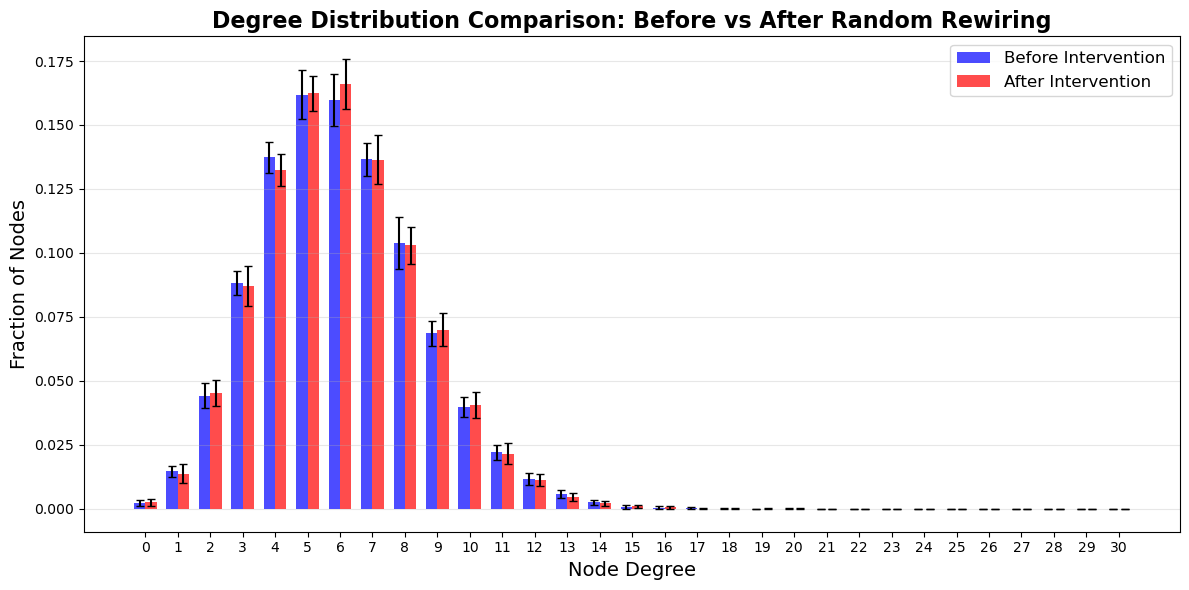

In [20]:
# ---------- 度分布对比直方图（在同一张图上）----------
if os.path.exists(deg_summary_before_file) and os.path.exists(deg_summary_after_file):
    deg_before = pd.read_csv(deg_summary_before_file)
    deg_after = pd.read_csv(deg_summary_after_file)
    
    # 为了更好的可视化，限制显示的度数范围
    max_deg_plot = 30  # 只显示0-30度的节点
    
    # 过滤数据
    deg_before_filtered = deg_before[deg_before['degree'] <= max_deg_plot]
    deg_after_filtered = deg_after[deg_after['degree'] <= max_deg_plot]
    
    # 创建完整的度数范围（从0到max_deg_plot）
    all_degrees = np.arange(0, max_deg_plot + 1)
    
    # 创建完整的数据框，确保两个数据集的度数范围一致
    deg_before_complete = pd.DataFrame({'degree': all_degrees})
    deg_after_complete = pd.DataFrame({'degree': all_degrees})
    
    # 合并数据，填充缺失的度数为0
    deg_before_complete = deg_before_complete.merge(deg_before_filtered, on='degree', how='left')
    deg_after_complete = deg_after_complete.merge(deg_after_filtered, on='degree', how='left')
    
    # 填充NaN值为0
    deg_before_complete = deg_before_complete.fillna(0)
    deg_after_complete = deg_after_complete.fillna(0)
    
    # 创建对比直方图
    plt.figure(figsize=(12, 6))
    
    # 设置柱状图的位置和宽度
    bar_width = 0.35
    x_pos = np.arange(len(all_degrees))
    
    # 绘制免疫前后的柱状图
    plt.bar(x_pos - bar_width/2, deg_before_complete['mean_fraction'], 
            bar_width, label='Before Intervention', 
            color='blue', alpha=0.7, yerr=deg_before_complete['std_fraction'], capsize=3)
    
    plt.bar(x_pos + bar_width/2, deg_after_complete['mean_fraction'], 
            bar_width, label='After Intervention', 
            color='red', alpha=0.7, yerr=deg_after_complete['std_fraction'], capsize=3)
    
    plt.xlabel("Node Degree", fontsize=14)
    plt.ylabel("Fraction of Nodes", fontsize=14)
    plt.title("Degree Distribution Comparison: Before vs After Random Rewiring", fontsize=16, fontweight='bold')
    plt.xticks(x_pos, all_degrees.astype(int))
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    
    if save_png:
        out_png2 = os.path.join(out_dir, png_name_deg_comparison)
        plt.savefig(out_png2, dpi=300, bbox_inches='tight')
        print(f"Saved degree distribution comparison histogram to {out_png2}")
    plt.show()